In [1]:
# import libreries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#upload data
df = pd.read_csv("../data/raw/ames.csv")

### Visualize dataframe

In [3]:
df.shape

(2930, 83)

In [4]:
df.head()

,Unnamed: 0,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 83 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       2930 non-null   int64  
 1   Order            2930 non-null   int64  
 2   PID              2930 non-null   int64  
 3   MS SubClass      2930 non-null   int64  
 4   MS Zoning        2930 non-null   str    
 5   Lot Frontage     2440 non-null   float64
 6   Lot Area         2930 non-null   int64  
 7   Street           2930 non-null   str    
 8   Alley            198 non-null    str    
 9   Lot Shape        2930 non-null   str    
 10  Land Contour     2930 non-null   str    
 11  Utilities        2930 non-null   str    
 12  Lot Config       2930 non-null   str    
 13  Land Slope       2930 non-null   str    
 14  Neighborhood     2930 non-null   str    
 15  Condition 1      2930 non-null   str    
 16  Condition 2      2930 non-null   str    
 17  Bldg Type        2930 non

In [6]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

# Exploratory Data Analysis — Ames Housing

## 1. Dataset overview
- The dataset contains **2,930 house sales** and **83 columns** (80 features, the target and 2 identifiers, plus an index column added when the CSV was saved).
- **Columns to drop:** `Unnamed: 0`, `Order` and `PID` are row/parcel identifiers. They carry no information about the house itself, and keeping them could let a model memorise IDs instead of learning real patterns.
- **Columns with many missing values:** `Pool QC` (2,917 missing), `Misc Feature` (2,824), `Alley` (2,732) and `Fence` (2,358).
  These are most likely **not data errors**: according to the dataset documentation, a missing value here means the house *has no* pool, alley access or fence. They will be encoded as an explicit "None" category rather than imputed.

## 2. Target variable: SalePrice
- **Half of the houses sell between $129,500 and $213,500** (IQR = $84,000), a fairly narrow central range compared with the full range ($12,789 – $755,000).
- **Mean vs. median:** the mean ($180,796) is about $21,000 above the median ($160,000), and the most expensive house is $595,000 above the median while the cheapest is only $147,000 below it. The distribution is **right-skewed**: a small number of expensive houses pull the mean up.
- **Log transform:** taking `log(SalePrice)` makes the distribution close to symmetric. This matters for the model: a linear regression on raw prices would be dominated by the few very expensive houses, and errors would grow with price. On the log scale, errors behave more like *percentage* errors, which is also how a buyer or agent thinks about price.

## 3. Next steps
- Drop the identifier columns.
- Treat "missing = feature absent" columns as an explicit "None" category.
- Model `log(SalePrice)` and convert predictions back to dollars for evaluation.
- Investigate the most expensive and cheapest sales as potential outliers.


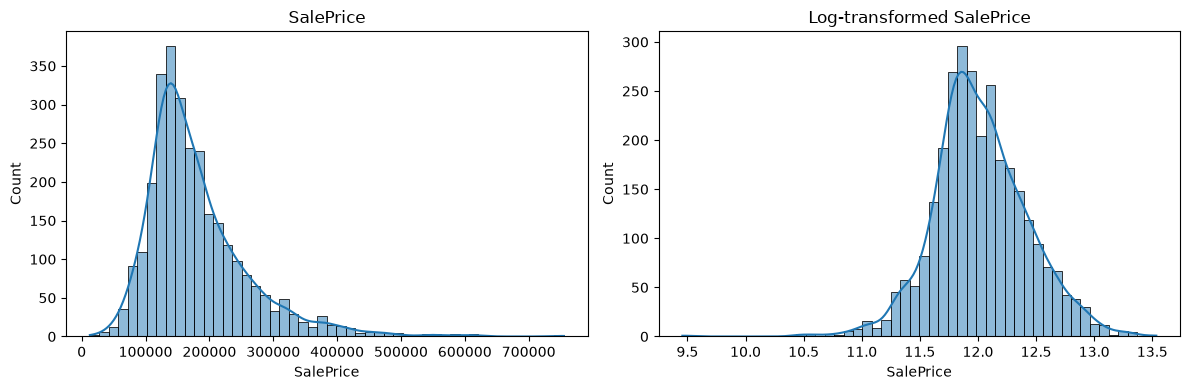

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["SalePrice"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("SalePrice")

sns.histplot(np.log1p(df["SalePrice"]), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Log-transformed SalePrice")

plt.tight_layout()

plt.savefig("../reports/figures/saleprice_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

- **Log transform:** `log(SalePrice)` is close to symmetric and centred around 12 (e¹² ≈ $163k, consistent with the median). A short left tail remains: a handful of very cheap sales (below ~$35k) that should be checked as potential outliers. Modelling on the log scale prevents the few very expensive houses from dominating the fit, and errors behave like *percentage* errors, which is how buyers and agents think about price.